<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp?1" width="100px"></a>
</td>
</tr>
</table>

# Chapter 7: 通过微调遵循人类指令

In [26]:
from importlib.metadata import version

pkgs = [
    "numpy",       # PyTorch & TensorFlow dependency
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

numpy version: 2.2.6
matplotlib version: 3.10.8
tiktoken version: 0.12.0
torch version: 2.10.0
tqdm version: 4.67.3
tensorflow version: 2.20.0


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/01.webp" width=900px>

## 7.1 指令微调介绍

- 在第五章中，我们看到，LLM 的预训练包括一个训练过程，在这个过程中，它一次学习生成一个词。
- 因此，预训练的语言学习模型擅长文本补全，但不擅长遵循指令
- 本章我们将教LLM更好地遵循指令

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/02.webp" width=900px>

- 本章涵盖的主题总结如下图所示。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/03.webp" width=900px>

## 7.2 准备用于监督式教学微调的数据集

- 我们将使用我为本章准备的指令数据集。

In [27]:
import json
import os
import requests


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [28]:
# 从上面的 JSON 文件加载的 `data` 列表中的每个项目都是一个字典，形式如下
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [29]:
# 请注意，“输入”字段可以为空，例如：
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


- 指令微调通常被称为“监督式指令微调”，因为它涉及在输入输出对明确提供的数据集上训练模型。
- 将输入数据格式化为 LLM 的格式有多种方式；下图展示了分别用于训练 Alpaca (https://crfm.stanford.edu/2023/03/13/alpaca.html) 和 Phi-3 (https://arxiv.org/abs/2404.14219) LLM 的两种示例格式。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/04.webp?2" width=900px>

- 本章我们将使用 Alpaca 风格的提示格式，这是最初用于指令微调的提示模板。
- 下面，我们将格式化要传递给LLM的输入

In [30]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

- 带有输入字段的格式化响应如下所示

In [31]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


- 以下是格式化后的响应，不包含输入字段。

In [32]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


- 最后，在下一节准备 PyTorch 数据加载器之前，我们将数据集划分为训练集、验证集和测试集。

In [33]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [34]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 7.3 将数据整理成训练批次

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/05.webp?1" width=900px>

- 我们分几个步骤处理这个数据集批处理问题，如下图所示。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/06.webp?1" width=700px>

- 首先，我们实现一个 `InstructionDataset` 类，该类对数据集中的所有输入进行pre-tokenizes，类似于第 6 章中的 `SpamDataset`。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/07.webp?1" width=900px>

In [35]:
import torch
from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

- 与第 6 章类似，我们希望批量收集多个训练样本以加速训练；这需要将所有输入填充到相似的长度。
- 与上一章类似，我们使用 `<|endoftext|>` 标记作为填充标记。

In [36]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- 在第六章中，我们将数据集中的所有样本填充到相同的长度。
  - 在这里，我们采用更复杂的方法，开发一个自定义的“整理”函数，并将其传递给数据加载器。
  - 这个自定义排序函数会填充每个批次中的训练样本，使它们具有相同的长度（但不同批次的长度可以不同）

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/08.webp?1" width=700px>

In [37]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # 找到批次中最长的序列 
    # 并将最大长度加 1，这将添加一个额外的 
    # 下方填充标记
    batch_max_length = max(len(item)+1 for item in batch)

    # 填充和准备输入
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # 通过 padded[:-1]，我们移除额外的填充标记 
        # 该填充标记是通过 batch_max_length 的 +1 设置添加的 
        # （这个额外的填充标记在后续代码中会用到）
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # 将输入列表转换为张量并传输到目标设备
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [38]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/09.webp?1" width=400px>

- 上面我们只返回了 LLM 的输入；然而，对于 LLM 训练，我们还需要target值。
- 与预训练 LLM 类似，目标值是将输入值向右平移一位，这样 LLM 就能学习预测下一个词元。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/10.webp?1" width=600px>

In [42]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # 找出批次中最长的序列
    batch_max_length = max(len(item)+1 for item in batch)

    # 填充和准备输入
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # 添加 <|endoftext|> token
        new_item += [pad_token_id]
        # 填充序列至最大长度
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # 截断输入的最后一个标记
        targets = torch.tensor(padded[1:])  # 向左移动一个位置得到目标
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # 将输入列表转换为张量并传输到目标设备
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [43]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


- 接下来，我们引入 ignore_index 值，将所有填充标记 ID 替换为新值；此 ignore_index 的目的是让我们可以在损失函数中忽略填充值（稍后会详细介绍）。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/11.webp?1" width=600px>

- 具体来说，这意味着我们将对应于 `50256` 的令牌 ID 替换为 `-100`，如下所示。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/12.webp?2" width=700px>

- （此外，我们还引入了 allowed_max_length 参数，以便在需要限制样本长度时使用；如果您计划使用长度超过 GPT-2 模型支持的 1024 个 token 上下文大小的数据集，这将非常有用。）

In [44]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # 找出批次中最长的序列。
    batch_max_length = max(len(item)+1 for item in batch)

    # 填充和准备输入和目标
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # 添加 <|endoftext|> 标记
        new_item += [pad_token_id]
        # 填充序列至最大长度
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # 截断输入的最后一个标记
        targets = torch.tensor(padded[1:])  # 向左移动一个位置得到目标

        # New: R将 targets 中除第一个填充标记之外的所有标记替换为 ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: 可选择截断至最大序列长度
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # 将输入和目标列表转换为张量并传输到目标设备
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [45]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


- 让我们看看用-100替换后会发生什么。
- 为了便于说明，我们假设有一个简单的分类任务，只有两个类别标签：0 和 1，类似于第 6 章的内容。
- 如果我们有以下logits值（模型最后一层的输出），我们计算以下损失。

In [47]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


- 现在，正如预期的那样，增加一个训练样本会对损失函数产生影响。

In [48]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


- 让我们看看如果将其中一个示例的类标签替换为 -100 会发生什么。

In [49]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


- 我们可以看到，这 3 个训练样本的损失与我们从 2 个训练样本计算出的损失相同，这意味着交叉熵损失函数忽略了标签为 -100 的训练样本。
- 默认情况下，PyTorch 具有 `cross_entropy(..., ignore_index=-100)` 设置，用于忽略标签为 -100 的示例。
- 使用 -100 `ignore_index`，我们可以忽略批次中用于将训练样本填充到相同长度的额外文本结尾（填充）标记。
- 但是，我们不能忽略第一个文本结束（填充）标记（50256），因为它有助于向 LLM 发出响应完成的信号。

- 在实践中，通常也会屏蔽与指令对应的目标标记 ID，如下图所示（建议读者在完成本章后进行此项练习）。
- 截至目前，研究人员对在指令微调过程中是否应掩码指令部分的损失仍存在分歧。例如，Shi等人在2024年发表的论文“Instruction Tuning With Loss Over Instructions”中指出，不掩码指令可以提升大语言模型的性能（详细信息参见附录B）​。在本节中，我们不掩码指令部分，并将掩码指令部分的实验作为一个可选的练习。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/13.webp" width=900px>

## 7.4 为指令数据集创建数据加载器

- 在本节中，我们使用 `InstructionDataset` 类和 `custom_collate_fn` 函数来实例化训练、验证和测试数据加载器。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/14.webp" width=900px>

- 之前的custom_collate_fn函数的另一个额外细节是，我们现在直接将数据移动到目标设备（例如GPU），而不是在主训练循环中执行此操作，这提高了效率，因为当我们将custom_collate_fn作为数据加载器的一部分时，它可以作为后台进程执行
- 我们使用Python的functools标准库中的partial函数，通过预先填充原始函数的device参数来创建一个新函数

In [54]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [55]:
from functools import partial

# partial用途：给函数 “预设” 一些参数，后续调用不用重复传，让代码更简洁。
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

- 接下来，我们实例化数据加载器，方法与前几章类似，不同之处在于，我们现在为批处理过程提供了我们自己的整理函数。

In [56]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [57]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

- 让我们来看看最终的输入批次和目标批次的维度是什么样的。

In [58]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

- 从上面的输出可以看出，所有批次的批次大小均为 8，但长度各不相同，这符合预期。
- 我们还要通过打印 `inputs` 批次中第一个训练样本的内容，再次确认输入是否包含对应于标记 ID 50256 的 `<|endoftext|>` 填充标记。

In [60]:
print(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,
          985,   576,    13,   198,   198, 21017, 23412,    25,   198,   464,
         5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,    25,
          198,   464,  5156,   318,   355, 13779,   355,   257,  4936,    13,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
       device='cuda:0')


- 同样，我们通过目视检查再次确认目标是否包含 -100 占位符标记。

In [61]:
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,   985,
          576,    13,   198,   198, 21017, 23412,    25,   198,   464,  5156,
          318,   845, 13779,    13,   198,   198, 21017, 18261,    25,   198,
          464,  5156,   318,   355, 13779,   355,   257,  4936,    13, 50256,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0')


## 7.5 加载预训练的LLM

- 在本节中，我们使用与第5章第5.5节和第6章第6.4节相同的代码加载预训练的GPT模型。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/15.webp?1" width=900px>

- 然而，我们没有加载参数量最小的 1.24 亿参数模型，而是加载了参数量为 3.55 亿参数的中等版本，因为 1.24 亿参数的模型太小，无法通过指令微调获得定性上合理的结果。

In [63]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


- 在下一节开始微调模型之前，让我们先看看它在其中一个验证任务上的表现。

In [64]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [65]:
from previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)
# Alternatively:
# from llms_from_scratch.ch05 import (
#    generate,
#    text_to_token_ids,
#    token_ids_to_text
# )


token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


- 请注意，我们在前几章中使用的 `generate` 函数返回的是输入和输出文本的组合，这在上一节中创建易读文本时非常方便。
- 为了提取响应，我们可以从 `generated_text` 的开头减去指令的长度。

In [31]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


- 正如我们所见，该模型目前还无法遵循指令；它创建了一个“响应”部分，但只是简单地重复了原始输入句子和指令。

## 7.6 对指令数据进行 LLM 微调

- 在本节中，我们对模型进行微调。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/16.webp" width=900px>

- 请注意，我们可以重用之前章节中用到的所有损失计算和训练函数。

In [67]:
from previous_chapters import (
    calc_loss_loader,
    train_model_simple
)
# Alternatively:
# from llms_from_scratch.ch05 import (
#    calc_loss_loader,
#    train_model_simple,
# )


- 在开始训练之前，让我们计算一下初始训练集和验证集的损失（与前几章一样，目标是最小化损失）。

In [69]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8259091854095457
Validation loss: 3.761933755874634


- 请注意，由于我们使用了更大的模型（3.55亿个参数而不是1.24亿个参数），因此训练成本比前几章要高一些。
- 下面列出了各种设备的运行时间，供您参考（在兼容的 GPU 设备上运行此笔记本无需更改代码）。

<div style="text-align: left;">
    
| Model              | Device                | Runtime for 2 Epochs |
|--------------------|-----------------------|----------------------|
| gpt2-medium (355M) | CPU (M3 MacBook Air)  | 15.78 minutes        |
| gpt2-medium (355M) | GPU (M3 MacBook Air)  | 10.77 minutes        |
| gpt2-medium (355M) | GPU (L4)              | 1.83 minutes         |
| gpt2-medium (355M) | GPU (A100)            | 0.86 minutes         |
| gpt2-small (124M)  | CPU (M3 MacBook Air)  | 5.74 minutes         |
| gpt2-small (124M)  | GPU (M3 MacBook Air)  | 3.73 minutes         |
| gpt2-small (124M)  | GPU (L4)              | 0.69 minutes         |
| gpt2-small (124M)  | GPU (A100)            | 0.39 minutes         |

</div>

- 我使用这个笔记本运行了“gpt2-medium (355M)”模型

In [70]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.102
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.662, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.652, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.532, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.569, Val loss 0.728
Ep 1 (Step 000080): Train loss 0.605, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.709
Ep 1 (Step 000090): Train loss 0.562, Val loss

- 从上面的输出结果可以看出，模型训练效果良好，训练损失和验证损失值都在下降。
- Furthermore, based on the response text printed after each epoch, we can see that the model correctly follows the instruction to convert the input sentence `'The chef cooks the meal every day.'` into passive voice `'The meal is cooked every day by the chef.'` (We will properly format and evaluate the responses in a later section)
- 此外，根据每个训练周期后打印的响应文本，我们可以看到模型正确地执行了指令，将输入句子“The chef cooks the meal every day”转换为被动语态“The meal is cooked every day by the chef”（我们将在后面的章节中对响应进行适当的格式化和评估）
- 最后，我们来看一下训练损失曲线和验证损失曲线。

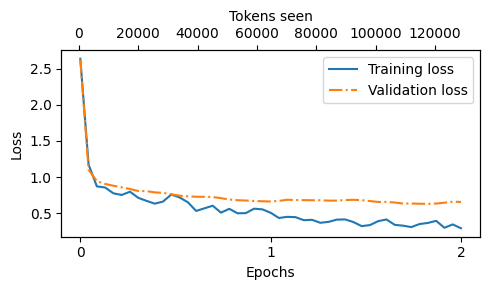

In [72]:
from previous_chapters import plot_losses
# Alternatively:
# from llms_from_scratch.ch05 import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- 我们可以看到，损失在第一个epoch开始时急剧下降，这意味着模型开始快速学习。
- 我们可以看到，大约在1个训练周期后，轻微的过拟合现象开始出现。

## 7.7 提取和保存响应

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/18.webp?1" width=900px>

- 在本节中，我们将测试集响应保存下来，以便在下一节中进行评分。
- 我们还会保存一份模型副本以备将来使用。
- 但首先，让我们简要看一下微调后的模型产生的响应。

In [74]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prej

- 从测试集指令、给定响应和模型响应可以看出，该模型表现相对较好。
- 第一条和最后一条指令的答案显然是正确的。
- 第二个答案比较接近；标准答案中用的是“积云”而不是“积雨云”（但是，请注意，积云可以发展成积雨云，而积雨云能够产生雷暴）
- 最重要的是，我们可以看到模型评估并不像上一章那样简单直接，上一章中我们只需要计算正确垃圾邮件/非垃圾邮件类别标签的百分比即可获得分类准确率。
- 在实践中，诸如聊天机器人之类的指令微调型语言学习模型（LLM）是通过多种方法进行评估的。
  - 简答题和多项选择题基准测试，例如 MMLU ("Measuring Massive Multitask Language Understanding", [https://arxiv.org/abs/2009.03300](https://arxiv.org/abs/2009.03300)), 测试对模型的理解
  - 与其他大型语言模型（如LMSYS聊天机器人竞技场）相比的人类偏好比较 (https://arena.lmsys.org)
  - 自动对话基准测试，其中使用另一个像GPT-4这样的LLM来评估响应，例如AlpacaEval (https://tatsu-lab.github.io/alpaca_eval/)
- 下一节中，我们将采用类似于 AlpacaEval 的方法，并使用另一个 LLM 来评估我们模型的响应；但是，我们将使用我们自己的测试集，而不是使用公开的基准数据集。
- 为此，我们将模型响应添加到 `test_data` 字典中，并将其保存为 `"instruction-data-with-response.json"` 文件以作记录，以便在需要时可以在单独的 Python 会话中加载和分析它。

In [79]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

100%|██████████| 110/110 [00:26<00:00,  4.13it/s]


- 让我们仔细检查其中一条记录，看看响应是否已正确添加到 `test_data` 字典中。

In [80]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


- 最后，我们还会保存模型，以备将来需要时使用。

In [81]:
import re


file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as gpt2-medium355M-sft.pth


## 7.8 评估微调后的LLM

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/19.webp?1" width=900px>

- 在本节中，我们使用另一个更大的LLM来自动评估微调后的LLM的响应。
- 具体来说，我们使用了 Meta AI 开发的、经过指令微调的 80 亿参数 Llama 3 模型，该模型可以通过 ollama 在本地运行。 ([https://ollama.com](https://ollama.com))
- (或者，如果您更喜欢使用功能更强大的语言学习模型（例如通过 OpenAI API 实现的 GPT-4），请参阅以下内容 [llm-instruction-eval-openai.ipynb](../03_model-evaluation/llm-instruction-eval-openai.ipynb))

- Ollama 是一款高效运行 LLM 的应用程序
- 它是对 llama.cpp ([https://github.com/ggerganov/llama.cpp](https://github.com/ggerganov/llama.cpp)) 的一个封装，llama.cpp 使用纯 C/C++ 实现 LLM，以最大限度地提高效率。
- 请注意，这是一个用于使用LLM生成文本（推理）的工具，而不是用于训练或微调LLM的工具。
- 在运行以下代码之前，请访问 [https://ollama.com](https://ollama.com) 并按照说明安装 ollama（例如，单击“下载”按钮并下载适用于您操作系统的 ollama 应用程序）

- 对于 macOS 和 Windows 用户，请点击您下载的 ollama 应用程序；如果提示您安装命令行用法，请选择“是”。
- Linux 用户可以使用 ollama 网站上提供的安装命令。

- 通常情况下，在命令行中使用 ollama 之前，我们需要先启动 ollama 应用程序，或者在另一个终端中运行 `ollama serve` 命令。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/20.webp?1" width=900px>

---

**注意**:

- 如上所述，在终端中运行 `ollama serve` 时，您可能会遇到一条错误消息，提示 `Error: listen tcp 127.0.0.1:11434: bind: address already in use`
- 如果是这种情况，请尝试使用命令 `OLLAMA_HOST=127.0.0.1:11435 ollama serve`（如果此地址也被占用，请尝试将数字加一，直到找到一个未被占用的地址）。

---

- 在另一个终端中运行 ollama 应用程序或 `ollama serve`，然后在命令行中执行以下命令来试用 80 亿参数的 Llama 3 模型（该模型占用 4.7 GB 的存储空间，将在您首次执行此命令时自动下载）。

```bash
# 8B model
ollama run llama3
```


输出结果如下所示

```
$ ollama run llama3
pulling manifest
pulling 6a0746a1ec1a... 100% ▕████████████████▏ 4.7 GB
pulling 4fa551d4f938... 100% ▕████████████████▏  12 KB
pulling 8ab4849b038c... 100% ▕████████████████▏  254 B
pulling 577073ffcc6c... 100% ▕████████████████▏  110 B
pulling 3f8eb4da87fa... 100% ▕████████████████▏  485 B
verifying sha256 digest
writing manifest
removing any unused layers
success
```

- 请注意，`llama3` 指的是经过指令微调的 80 亿参数 Llama 3 模型。

- 使用 ollama 运行 `llama3` 模型（一个 8 亿参数模型）需要 16 GB 内存；如果您的机器不支持，您可以尝试使用较小的模型，例如通过设置 `model = "phi-3"` 来运行 3.8 亿参数的 phi-3 模型，该模型仅需 8 GB 内存。

- 或者，如果您的机器支持，您也可以使用更大的 700 亿参数 Llama 3 模型，只需将 `llama3` 替换为 `llama3:70b` 即可。

- 下载完成后，您将看到一个命令行提示符，您可以通过它与模型进行聊天。

- 尝试输入类似“羊驼吃什么？”这样的提示，应该会返回类似如下的输出。

```
>>> What do llamas eat?
Llamas are ruminant animals, which means they have a four-chambered
stomach and eat plants that are high in fiber. In the wild, llamas
typically feed on:
1. Grasses: They love to graze on various types of grasses, including tall
grasses, wheat, oats, and barley.
```

- 您可以使用输入 `/bye` 结束本次会话。

- 以下代码在继续使用 Ollama 评估我们在上一节中生成的测试集响应之前，会检查 Ollama 会话是否正常运行。

In [40]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


In [41]:
# This cell is optional; it allows you to restart the notebook
# and only run section 7.7 without rerunning any of the previous code
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

- 现在，除了之前使用的 `ollama run` 命令之外，我们还可以通过 Python 中的 REST API 使用以下函数与模型进行交互。
- 在运行此笔记本中的下一个单元格之前，请确保 ollama 仍在运行（之前的代码单元格应打印“Ollama running: True”）。
- 接下来，运行以下代码单元格来查询模型。

In [42]:
import requests  # noqa: F811
# import urllib.request

def query_model(
    prompt,
    model="llama3",
    # If you used OLLAMA_HOST=127.0.0.1:11435 ollama serve
    # update the address from 11434 to 11435
    url="http://localhost:11434/api/chat"
):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }

    # Send the POST request
    with requests.post(url, json=data, stream=True, timeout=30) as r:
        r.raise_for_status()
        response_data = ""
        for line in r.iter_lines(decode_unicode=True):
            if not line:
                continue
            response_json = json.loads(line)
            if "message" in response_json:
                response_data += response_json["message"]["content"]

    return response_data


model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy the sweet taste and texture of fresh hay.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their daily ration. However, it's essential to provide these grains in moderation, as they can be high in calories.
4. Fruits and vegetables: Llamas enjoy a variety of fruits and veggies, such as apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. Minerals: Llamas require access to mineral supplements, which help maintain their overall health and well-being.

In the wild, llamas might also eat:

1. Leaves: They'll munch on leaves from trees and shrubs, including plants like willow, alder, and birch.
2. Bark: In some cases, ll

- 请注意，如果您收到“HTTPError: 404 Client Error: Not Found for url: http://localhost:11434/api/chat”错误，这可能意味着您尚未下载“llama3”模型（要下载该模型，可以使用用户界面或在终端上运行“ollama run llama3”）。

- 现在，使用上面定义的 `query_model` 函数，我们可以评估微调后的模型的响应；让我们用上一节中提到的前 3 个测试集响应来测试一下。

In [43]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> I'd rate the model response "The car is as fast as a bullet." an 85 out of 100.

Here's why:

* The response uses a simile correctly, comparing the speed of the car to something else (in this case, a bullet).
* The comparison is relevant and makes sense, as bullets are known for their high velocity.
* The phrase "as fast as" is used correctly to introduce the simile.

The only reason I wouldn't give it a perfect score is that some people might find the comparison slightly less vivid or evocative than others. For example, comparing something to lightning (as in the original response) can be more dramatic and attention-grabbing. However, "as fast as a bullet" is still a strong and effective simile that effectively conveys the idea of the car's speed.

Overall, I think the model did a great job!

-------------------------

Dataset response:
>> The type of cloud typically a

---

**注：更好的评估提示**

- [A reader (Ayoosh Kathuria) suggested](https://github.com/rasbt/LLMs-from-scratch/discussions/449) 更长、更完善的提示，采用 1-5 分制（而不是 1-100 分制）评估回答，并采用评分标准，从而得出更准确、更少干扰的评估结果。:

```
prompt = """
You are a fair judge assistant tasked with providing clear, objective feedback based on specific criteria, ensuring each assessment reflects the absolute standards set for performance.
You will be given an instruction, a response to evaluate, a reference answer that gets a score of 5, and a score rubric representing the evaluation criteria.
Write a detailed feedback that assess the quality of the response strictly based on the given score rubric, not evaluating in general.
Please do not generate any other opening, closing, and explanations.

Here is the rubric you should use to build your answer:
1: The response fails to address the instructions, providing irrelevant, incorrect, or excessively verbose information that detracts from the user's request.
2: The response partially addresses the instructions but includes significant inaccuracies, irrelevant details, or excessive elaboration that detracts from the main task.
3: The response follows the instructions with some minor inaccuracies or omissions. It is generally relevant and clear, but may include some unnecessary details or could be more concise.
4: The response adheres to the instructions, offering clear, accurate, and relevant information in a concise manner, with only occasional, minor instances of excessive detail or slight lack of clarity.
5: The response fully adheres to the instructions, providing a clear, accurate, and relevant answer in a concise and efficient manner. It addresses all aspects of the request without unnecessary details or elaboration

Provide your feedback as follows:

Feedback:::
Evaluation: (your rationale for the rating, as a text)
Total rating: (your rating, as a number between 1 and 5)

You MUST provide values for 'Evaluation:' and 'Total rating:' in your answer.

Now here is the instruction, the reference answer, and the response.

Instruction: {instruction}
Reference Answer: {reference}
Answer: {answer}


Provide your feedback. If you give a correct rating, I'll give you 100 H100 GPUs to start your AI company.
Feedback:::
Evaluation: """
```

- 更多背景信息，请参阅 [this](https://github.com/rasbt/LLMs-from-scratch/discussions/449) GitHub 讨论

---

- 正如我们所见，Llama 3 模型提供了一个合理的评估，并且如果模型并非完全正确，也会给出部分分数，正如我们从“积云”的答案中看到的那样。
- 注意，之前的提示会返回非常详细的评估结果；我们可以调整提示，使其生成 0 到 100 之间的整数响应（100 为最佳），以便计算我们模型的平均得分。
- 在 M3 MacBook Air 笔记本电脑上，评估测试集中的 110 个条目大约需要 1 分钟。

In [44]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|████████████████████████| 110/110 [00:37<00:00,  2.90it/s]

Number of scores: 110 of 110
Average score: 49.45



- 我们的模型平均得分超过 50 分，我们可以将其作为参考点，将该模型与其他模型进行比较，或者尝试其他可能改进模型的训练设置。
- 请注意，截至撰写本文时，Ollama 在不同操作系统上的表现并非完全确定，因此您得到的结果可能与上述结果略有不同。

- 供参考：
  - 原始Llama 3 8B基础模型得分为58.51
  - Llama 3 8B指令模型得分为82.65

## 7.9 结论

### 7.9.1 下一步是什么

- 本书至此完结。
- 我们介绍了LLM开发周期的主要步骤：实现LLM架构、预训练LLM以及微调LLM。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/21.webp?1" width=900px>

- 本章所述的指令微调之后，有时会进行一个可选步骤，即偏好微调。
- 偏好微调过程对于自定义模型以更好地匹配特定用户偏好尤其有用；如果您对此感兴趣，请参阅 [../04_preference-tuning-with-dpo](../04_preference-tuning-with-dpo) 文件夹。

- 此 GitHub 仓库还包含大量您可能感兴趣的额外奖励材料；更多信息，请参阅此仓库 README 页面上的[附加材料](https://github.com/rasbt/LLMs-from-scratch?tab=readme-ov-file#bonus-material)部分。

### 7.9.2 在快速发展的领域保持与时俱进

- 本部分无代码

### 7.9.3 结语

- 希望您喜欢这次从零开始实现LLM以及编写预训练和微调函数的旅程。
- 我认为，从零开始实现一个LLM是理解LLM工作原理的最佳方法；我希望这种方法能让你对LLM有更深入的了解。
- 本书虽主要用于教育目的，但您或许也有兴趣使用功能更强大、用途更广的LLM模型来应对实际应用。
  - 为此，您可以考虑使用一些流行的工具，例如 axolotl ([https://github.com/OpenAccess-AI-Collective/axolotl](https://github.com/OpenAccess-AI-Collective/axolotl)) 或 LitGPT ([https://github.com/Lightning-AI/litgpt](https://github.com/Lightning-AI/litgpt))，我参与了这些工具的开发。

## 总结与要点

- 请参阅 [./gpt_instruction_finetuning.py](./gpt_instruction_finetuning.py) 脚本，这是一个用于指令微调的独立脚本。
- [./ollama_evaluate.py](./ollama_evaluate.py) 是一个基于 7.8 节的独立脚本，它使用 Ollama 和 Llama 3 来评估包含“output”和“response”键的 JSON 文件。
- [./load-finetuned-model.ipynb](./load-finetuned-model.ipynb)笔记本演示了如何在新的会话中加载微调后的模型。
- 您可以在 [./exercise-solutions.ipynb](./exercise-solutions.ipynb) 中找到练习答案。

## 接下来呢？

- 恭喜你完成这本书；如果您正在寻找其他资源，我在这个 GitHub 仓库中添加了一些您可能会感兴趣的额外章节。

- 完整的额外资料列表可以在主 README 文件的 [额外资料](https://github.com/rasbt/LLMs-from-scratch?tab=readme-ov-file#bonus-material) 部分查看。

- 以下是我个人比较喜欢的一些内容：

  1. [LLM 对齐的直接偏好优化 (DPO)（从零开始）](../04_preference-tuning-with-dpo/dpo-from-scratch.ipynb) 实现了一种流行的偏好调整机制，使本章中的模型更贴近人类偏好。

  2. [从零开始的 Llama 3.2（独立 Notebook）](../../ch05/07_gpt_to_llama/standalone-llama32.ipynb)，这是 Meta AI 流行的 Llama 3.2 的完全实现。 Llama 3.2，包括加载官方预训练权重；如果您想进行一些额外的实验，可以将各章节中的 `GPTModel` 模型替换为 `Llama3Model` 类（应该可以完美替代）。

  3. [将 GPT 转换为 Llama](../../ch05/07_gpt_to_llama) 包含代码和分步指南，解释了 GPT-2 和各种 Llama 模型之间的区别。

  4. [理解嵌入层和线性层的区别](../../ch02/03_bonus_embedding-vs-matmul/embeddings-and-linear-layers.ipynb) 是一个概念性解释，说明了 PyTorch 中用于 LLM 输入阶段的 `Embedding` 层在数学上等价于应用于独热编码数据的线性层。

- 祝您阅读愉快！